***Instalando e importando bibliotecas:***

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

***Bibliotecas:***

In [2]:
# Bibliotecas de manipulação e visualização de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Algoritmos de clusterização
from sklearn.cluster import KMeans  
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Fixando seed 
SEED = 42
np.random.seed(SEED)

***Carregamento dos Dados:***

In [3]:
# Faz a leitura do dataset de transações com cartão de crédito
# Cada linha é uma transação; 'Class' indica fraude (1) ou legítima (0)
df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Questão 1:

***1.Análise exploratória:***

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


***1.1.Análise de Classe:***

In [5]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=" * 45)
print("DISTRIBUIÇÃO DAS CLASSES")
print("=" * 45)
print(f"  {'Classe':<12} {'Quantidade':>10} {'Porcentagem':>12}")
print("-" * 45)
for classe in class_counts.index:
    label = "Legítima (0)" if classe == 0 else "Fraude (1)"
    print(f"  {label:<12} {class_counts[classe]:>10} {class_pct[classe]:>11.3f}%")
print("=" * 45)

DISTRIBUIÇÃO DAS CLASSES
  Classe       Quantidade  Porcentagem
---------------------------------------------
  Legítima (0)     284315      99.827%
  Fraude (1)          492       0.173%


***1.2.Histogramas (Amount e Time):***

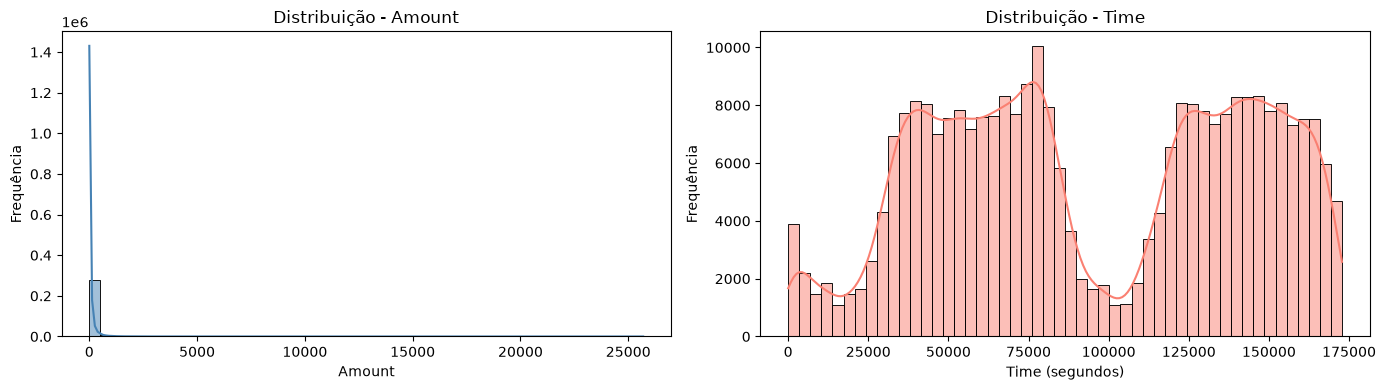

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount:
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição - Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequência')

# Time:
sns.histplot(df['Time'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição - Time')
axes[1].set_xlabel('Time (segundos)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

***2.Valores ausentes:***

*2.1.Análise de Valores Ausentes:*

In [7]:
ausentes = df.isnull().sum()
porcentagem = (ausentes / len(df)) * 100

resumo = pd.DataFrame({
    'Ausentes': ausentes,
    'Porcentagem (%)': porcentagem.round(2)
})

print(resumo[resumo['Ausentes'] > 0])

Empty DataFrame
Columns: [Ausentes, Porcentagem (%)]
Index: []


*2.2.Tratamento dos Valores Ausentes:*

In [8]:
if ausentes.sum() > 0: # Preenche os valores ausentes com a média da coluna
    df.fillna(df.mean(), inplace=True)
    print("Valores ausentes encontrados e preenchidos com a média.")
    
else:
    print("Não há valores ausentes no dataset.")

Não há valores ausentes no dataset.


***3.Redundância e inconsistência:***

*3.1.Detecção e remoção de registros duplicados(redundantes):*

In [9]:
duplicados = df.duplicated().sum()
print('Duplicados:', duplicados)

print("Antes:", df.shape)
df.drop_duplicates(keep='first', inplace=True) # Remove registros idênticos, mantendo a primeira ocorrência
print("Depois:", df.shape)

Duplicados: 1081
Antes: (284807, 31)
Depois: (283726, 31)


*3.2.Detecção e remoção de registros inconsistentes:*

In [10]:
df.describe().T

np.isinf(df).sum().sum() # como o csv possui é numerico, podemos verificar se há valores infinitos
print("Valores infinitos encontrados:", np.isinf(df).sum().sum())
df.replace([np.inf, -np.inf], np.nan, inplace=True)

Valores infinitos encontrados: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


***4.Análise de correlação e multicolinearidade:***

*4.1.Examinando as correlações:*

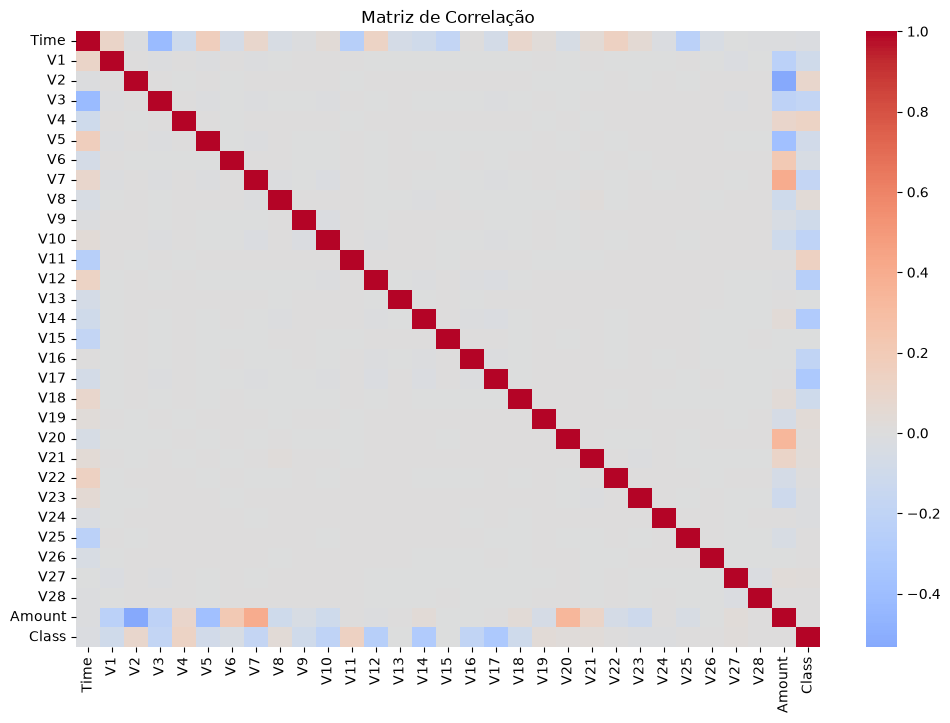

In [11]:
correlacao = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de Correlação')
plt.show()

#### Conclusão da Análise de Correlação

O heatmap confirma que:

- **Baixa correlação entre V1–V28:** como esperado para componentes de PCA,
  as variáveis são aproximadamente ortogonais entre si, o que elimina o problema
  de multicolinearidade nesse subconjunto de atributos.

- **Time e Amount:** apresentam correlações fracas com as demais variáveis,
  sem representar risco de multicolinearidade relevante para o modelo.

- **Class:** possui correlações fracas a moderadas com algumas componentes
  (especialmente V17, V14 e V12, com valores negativos), o que indica que
  nenhuma variável isolada é suficiente para detectar fraude, o modelo precisa
  combinar múltiplos atributos para classificar corretamente.

- **Ausência de multicolinearidade grave:** não há pares de variáveis preditoras
  com correlação próxima de 1 ou -1, o que é positivo para a estabilidade
  e interpretabilidade do modelo.

Em resumo, o heatmap confirma que o conjunto de dados está bem condicionado
para o treinamento, sem redundâncias expressivas entre os atributos.

***5.Divisão treino–teste estratificada:***

In [12]:
X = df.drop('Class', axis=1)  # Features
y = df['Class']                # Alvo (fraude ou não)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% teste, 80% treino
    stratify=y,     # mantém a proporção das classes
    random_state=SEED
)

print("=" * 45)
print("DIVISÃO TREINO — TESTE")
print("=" * 45)
print(f"  Total de amostras : {len(df)}")
print(f"  Treino            : {X_train.shape[0]}")
print(f"  Teste             : {X_test.shape[0]}")
print(f"  Features          : {X_train.shape[1]}")
print("-" * 45)
print(f"  Fraudes no treino : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"  Fraudes no teste  : {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print("=" * 45)

DIVISÃO TREINO — TESTE
  Total de amostras : 283726
  Treino            : 226980
  Teste             : 56746
  Features          : 30
---------------------------------------------
  Fraudes no treino : 378 (0.167%)
  Fraudes no teste  : 95 (0.167%)


***6.Outliers:***

***6.1.Boxplot:***

***6.1.1.Boxplot de Amount:***

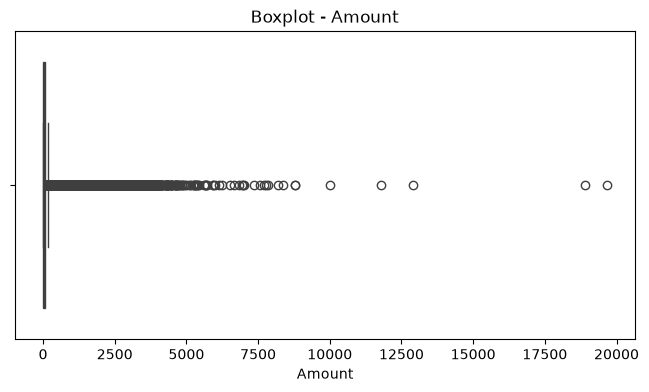

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=X_train['Amount'])
plt.title('Boxplot - Amount')
plt.show()

***6.1.2.Boxplot de Time:***

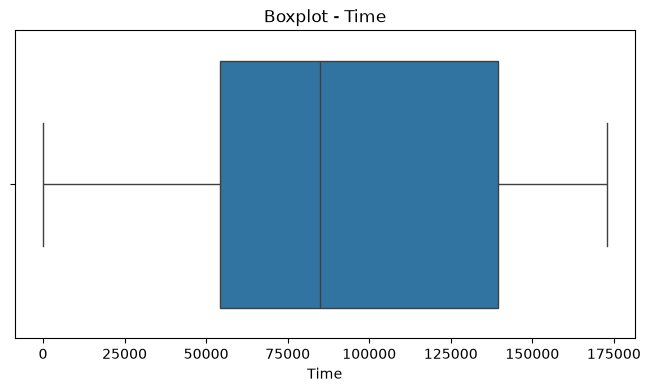

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=X_train['Time'])
plt.title('Boxplot - Time')
plt.show()

***6.2.Cálculo de outliers:***

***6.2.1.Cálculo de outliers em Amount:***

In [15]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_amount = df[
    (df['Amount'] < limite_inferior) |
    (df['Amount'] > limite_superior)
]

print("=" * 45)
print("OUTLIERS — Amount")
print("=" * 45)
print(f"  Q1               : {Q1:.2f}")
print(f"  Q3               : {Q3:.2f}")
print(f"  IQR              : {IQR:.2f}")
print(f"  Limite inferior  : {limite_inferior:.2f}")
print(f"  Limite superior  : {limite_superior:.2f}")
print("-" * 45)
print(f"  Outliers encontrados : {len(outliers_amount)}")
print(f"  % do dataset         : {len(outliers_amount)/len(df)*100:.2f}%")
print("=" * 45)

OUTLIERS — Amount
  Q1               : 5.60
  Q3               : 77.51
  IQR              : 71.91
  Limite inferior  : -102.27
  Limite superior  : 185.38
---------------------------------------------
  Outliers encontrados : 31685
  % do dataset         : 11.17%


***6.2.2.Cálculo de outliers em Time:***

In [16]:
Q1 = df['Time'].quantile(0.25)
Q3 = df['Time'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_time = df[
    (df['Time'] < limite_inferior) |
    (df['Time'] > limite_superior)
]

print("=" * 45)
print("OUTLIERS — Time")
print("=" * 45)
print(f"  Q1               : {Q1:.2f}")
print(f"  Q3               : {Q3:.2f}")
print(f"  IQR              : {IQR:.2f}")
print(f"  Limite inferior  : {limite_inferior:.2f}")
print(f"  Limite superior  : {limite_superior:.2f}")
print("-" * 45)
print(f"  Outliers encontrados : {len(outliers_time)}")
print(f"  % do dataset         : {len(outliers_time)/len(df)*100:.2f}%")
print("=" * 45)

OUTLIERS — Time
  Q1               : 54204.75
  Q3               : 139298.00
  IQR              : 85093.25
  Limite inferior  : -73435.12
  Limite superior  : 266937.88
---------------------------------------------
  Outliers encontrados : 0
  % do dataset         : 0.00%


#### Discussão: Outliers e Detecção de Fraude

A análise pelo método IQR identificou outliers nas variáveis Amount e Time.
No contexto de detecção de fraude, a remoção de outliers deve ser feita com
cautela, pelos seguintes motivos:

- **Outliers podem ser fraudes:** transações fraudulentas frequentemente
  apresentam valores atípicos (ex.: valores muito altos ou horários incomuns),
  ou seja, os outliers podem coincidir exatamente com a classe minoritária
  (Class=1) que desejamos detectar.

- **Remover outliers = perder fraudes:** se removermos esses registros,
  podemos estar descartando justamente os casos mais importantes para o
  treinamento do modelo.

Por esses motivos, optamos por **não remover os outliers** neste pipeline,
preservando todas as transações suspeitas para que o modelo possa aprender
a identificá-las corretamente.

***7.Normalização/padronização:***

In [17]:
scaler = StandardScaler()

# Treina o scaler apenas no treino para evitar data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma escala no teste, sem reajustar
X_test_scaled = scaler.transform(X_test)

***8.Codificação de variáveis:***

In [18]:
print("=" * 45)
print("TIPOS DAS VARIÁVEIS")
print("=" * 45)
print(df.dtypes)
print("=" * 45)

# Não foram identificadas variáveis categóricas no conjunto de dados, pois todas as variáveis são numéricas.

TIPOS DAS VARIÁVEIS
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


***9.Balanceamento de classe:***

In [19]:
smote = SMOTE(random_state=SEED)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

antes = y_train.value_counts()
depois = pd.Series(y_train_bal).value_counts()

print("=" * 45)
print("BALANCEAMENTO COM SMOTE")
print("=" * 45)
print(f"{'Classe':<12} {'Antes':>10} {'Depois':>10}")
print("-" * 45)
for classe in sorted(antes.index):
    label = "Legítima (0)" if classe == 0 else "Fraude (1)"
    print(f"{label:<12} {antes[classe]:>10} {depois[classe]:>10}")
print("=" * 45)
print(f"\nAmostras sintéticas geradas: {depois[1] - antes[1]}")
print(f"Total de amostras após SMOTE: {len(y_train_bal)}")

BALANCEAMENTO COM SMOTE
Classe            Antes     Depois
---------------------------------------------
Legítima (0)     226602     226602
Fraude (1)          378     226602

Amostras sintéticas geradas: 226224
Total de amostras após SMOTE: 453204


## Treinamento do Modelo:

#### Justificativa do Modelo: Random Forest

O modelo escolhido foi o classificador ***Random Forest***, pelos seguintes motivos:

- **Robusto a outliers:** por ser baseado em árvores de decisão, não é
  sensível a valores extremos como modelos lineares seriam.
- **Não assume distribuição dos dados:** ideal para este dataset, onde
  Amount e Time têm distribuições assimétricas.
- **Bom desempenho em dados desbalanceados:** especialmente após o
  balanceamento com SMOTE, o Random Forest tende a generalizar bem
  para a classe minoritária.
- **Lida bem com muitas variáveis:** com 30 atributos, o ensemble de
  árvores seleciona subconjuntos aleatórios de features, reduzindo
  overfitting.
- **Interpretabilidade parcial:** permite extrair a importância das
  variáveis, útil para análises futuras.

In [20]:
model = RandomForestClassifier(
    random_state=SEED,
    n_estimators=100, # Número de árvores no ensemble
    n_jobs=-1
)

model.fit(X_train_bal, y_train_bal)

pred = model.predict(X_test_scaled)

## Avaliação:

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     56651
  Fraude (1)       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

MÉTRICAS — CLASSE FRAUDE (1)
  Precision : 0.9125
  Recall    : 0.7684
  F1-Score  : 0.8343
  Support   : 95 transações fraudulentas no teste


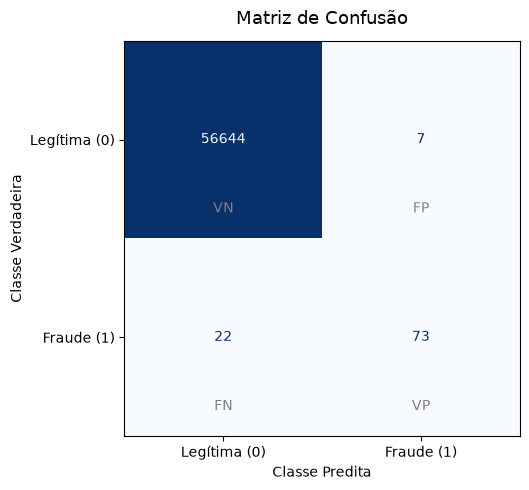

In [21]:

# Relatório completo de classificação
print("=" * 55)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("=" * 55)
print(classification_report(y_test, pred, target_names=["Legítima (0)", "Fraude (1)"]))

# Métricas da classe minoritária (foco principal)
print("=" * 55)
print("MÉTRICAS — CLASSE FRAUDE (1)")
print("=" * 55)
print(f"  Precision : {precision_score(y_test, pred):.4f}")
print(f"  Recall    : {recall_score(y_test, pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, pred):.4f}")
print(f"  Support   : {int((y_test == 1).sum())} transações fraudulentas no teste")
print("=" * 55)

# Matriz de confusão
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legítima (0)", "Fraude (1)"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

# Anotações manuais com rótulos VP/FP/FN/VN
labels = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.35, labels[i][j],
                ha="center", va="center",
                fontsize=10, color="gray")

plt.title("Matriz de Confusão", fontsize=13, pad=12)
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.show()

## Avaliação da Performance do Modelo

O modelo Random Forest foi treinado no conjunto de treino balanceado pelo SMOTE
e avaliado no conjunto de teste com a distribuição original (desbalanceada),
simulando um cenário real de detecção de fraude.

Como a base é fortemente desbalanceada (apenas 0,172% de fraudes), a acurácia
isolada não é uma boa métrica, um modelo que previsse tudo como legítimo
atingiria ~99,8% de acurácia sem detectar nenhuma fraude. Por isso, as métricas
foco são precision, recall e F1 da classe minoritária (Classe 1).

**Resultados para a classe 1 (fraude):**

| Métrica   | Valor  |
|-----------|--------|
| Precision | 0.9125 |
| Recall    | 0.7684 |
| F1-Score  | 0.8343 |

**Matriz de Confusão:**

|                  | Predito: Classe 0 | Predito: Classe 1 |
|------------------|-------------------|-------------------|
| Real: Classe 0   | 56.644 (VP)       | 7 (FP)            |
| Real: Classe 1   | 22 (FN)           | 73 (VP)           |

**Interpretação:**

- O modelo acertou 73 das 95 fraudes presentes no conjunto de teste (**recall de 76,8%**),
  ou seja, deixou passar 22 transações fraudulentas (falsos negativos).

- Das transações classificadas como fraude, 91,25% eram de fato fraudes
  (**precision de 91,25%**), gerando apenas 7 alarmes falsos entre 56.651 transações legítimas.

- O **F1-Score de 0.83** indica um bom equilíbrio entre precision e recall,
  considerando o forte desbalanceamento do dataset.

- A acurácia geral de 99,97% reflete a dominância da classe 0, confirmando que
  ela não deve ser usada como métrica principal neste contexto.

# Questão 2:

## Amostragem Aleatória dos Dados para Clusterização:

In [22]:
X_cluster = X_train_scaled

amostra = pd.DataFrame(X_cluster).sample(
    frac=0.10,
    random_state=SEED
)

print(amostra.shape)

(22698, 30)


## Método do Cotovelo:

In [23]:
sse = []

for k in range(2, 6):

    kmeans = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10
    )

    kmeans.fit(amostra)

    sse.append(kmeans.inertia_)

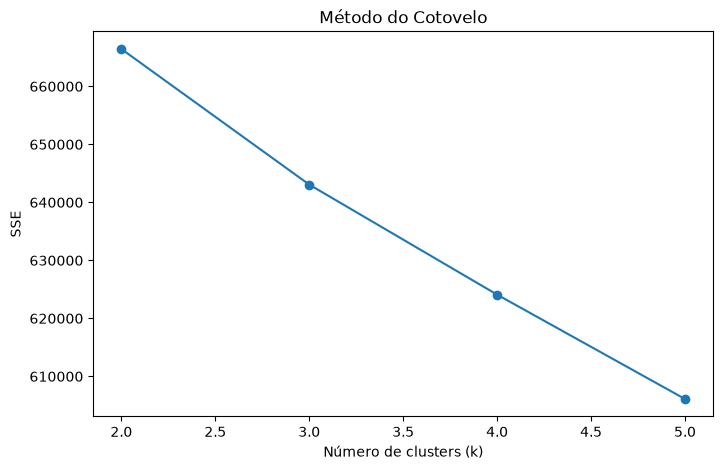

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(2,6), sse, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('SSE')
plt.title('Método do Cotovelo')

plt.show()

*Escolha do melhor k*

A partir do gráfico do Método do Cotovelo, observa-se que a curva do SSE apresenta uma redução mais acentuada até k=2, após o qual a queda passa a ser menos expressiva, caracterizando o "cotovelo" da curva.

In [25]:
melhor_k = 2  # escolhido com base no cotovelo identificado no gráfico acima

kmeans = KMeans(
    n_clusters=melhor_k,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(amostra)

sse_kmeans = kmeans.inertia_
silhouette_kmeans = silhouette_score(
    amostra,
    labels_kmeans
)

print("SSE:", sse_kmeans)
# Silhouette: mede coesão e separação dos clusters (-1 a 1, quanto maior melhor)
print("Silhouette:", silhouette_kmeans)

SSE: 666439.5277458162
Silhouette: 0.06644537517056888


## DBSCAN

In [26]:
dbscan = DBSCAN()

labels_db = dbscan.fit_predict(amostra)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_outliers = list(labels_db).count(-1)

print('Clusters:', n_clusters)
print('Outliers:', n_outliers)

if n_clusters > 1:
    sil_dbscan = silhouette_score(amostra, labels_db)
    print('Silhouette:', sil_dbscan)
else:
    sil_dbscan = None

Clusters: 99
Outliers: 21349
Silhouette: -0.40148644567247793


## Avaliação da qualidade: 

In [27]:
resultados = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN'],
    'Nº Clusters': [kmeans.n_clusters if hasattr(kmeans, "n_clusters") else len(set(labels_kmeans)), n_clusters],
    'Outliers': [0, n_outliers],
    'Silhouette': [silhouette_kmeans, sil_dbscan],
    'SSE': [sse_kmeans, None]  # DBSCAN não tem SSE padrão
})

resultados

,Algoritmo,Nº Clusters,Outliers,Silhouette,SSE
0,K-Means,2,0,0.066445,666439.527746
1,DBSCAN,99,21349,-0.401486,NaN


## Avaliação da Qualidade dos Agrupamentos

**Tabela comparativa:**

| Algoritmo | Nº Clusters | Outliers | Silhouette | SSE           |
|-----------|-------------|----------|------------|---------------|
| K-Means   | 2           | 0        | 0.0664     | 666.439,53    |
| DBSCAN    | 99          | 21.349   | -0.4015    | N/A           |

---

**K-Means(k = 2):**

O método do cotovelo indicou k = 2 como melhor valor, com SSE de **666.439,53**.
O SSE mede a soma das distâncias quadráticas de cada ponto ao centroide do seu
cluster(quanto menor, mais compactos são os grupos).

O coeficiente de silhueta obtido foi de **0.0664**, o que indica que 
os clusters formados têm baixa separação entre si. Isso é esperado
neste dataset: as variáveis V1–V28 são componentes de PCA distribuídos em um
espaço de alta dimensionalidade, sem agrupamentos naturalmente bem delimitados.

---

**DBSCAN(eps = 0.5, min_samples = 5):**

O DBSCAN identificou **99 clusters** e classificou **21.349 pontos como outliers**, o que representa aproximadamente 37% da amostra utilizada.

O coeficiente de silhueta de **-0.4015**, o que indica má qualidade dos
agrupamentos, muitos pontos estão mais próximos de clusters vizinhos do que
do próprio cluster atribuído. Isso sugere que os parâmetros padrão (eps = 0.5,
min_samples = 5) são inadequados para este dataset de alta dimensionalidade,
onde a noção de "vizinhança" é muito mais dispersa.

O SSE não se aplica ao DBSCAN, pois o algoritmo não define centroides.

---

**Conclusão:**

Portanto, considerando as métricas obtidas, o **K-Means com k = 2** apresentou
resultados mais consistentes para este conjunto de dados, sendo também compatível
com a natureza binária do problema original (fraude x legítima). O DBSCAN, por
sua vez, mostrou dificuldades em identificar estruturas de agrupamento adequadas
com os parâmetros padrão, produzindo um número excessivo de clusters e outliers.